# 📊 ChampIntel — Exploratory Data Analysis (EDA)

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
RAW_DATA_PATH = os.path.join("..", "datasets", "raw", "matches.csv")
print("✅ Library EDA siap!")

✅ Library EDA siap!


# Sel 2 (Code) — Import Library

In [9]:
df = pd.read_csv(RAW_DATA_PATH)
df.columns = df.columns.str.strip()

print(f"📊 Total Pertandingan: {df.shape[0]:,} laga")
print(f"📋 Total Kolom: {df.shape[1]}")
df.head(5)

📊 Total Pertandingan: 25,979 laga
📋 Total Kolom: 9


,date,season,stage,home_team,away_team,score,home_goals,away_goals,result
0,2008-08-17 00:00:00,2008/2009,1,KRC Genk,Beerschot AC,1–1,1,1,Draw
1,2008-08-16 00:00:00,2008/2009,1,SV Zulte-Waregem,Sporting Lokeren,0–0,0,0,Draw
2,2008-08-16 00:00:00,2008/2009,1,KSV Cercle Brugge,RSC Anderlecht,0–3,0,3,Away Win
3,2008-08-17 00:00:00,2008/2009,1,KAA Gent,RAEC Mons,5–0,5,0,Home Win
4,2008-08-16 00:00:00,2008/2009,1,FCV Dender EH,Standard de Liège,1–3,1,3,Away Win


# Memuat Data & Ringkasan Struktur

In [10]:
df = pd.read_csv(RAW_DATA_PATH)
df.columns = df.columns.str.strip()

print(f"📊 Total Pertandingan: {df.shape[0]:,} laga")
print(f"📋 Total Kolom: {df.shape[1]}")
df.head(5)

📊 Total Pertandingan: 25,979 laga
📋 Total Kolom: 9


,date,season,stage,home_team,away_team,score,home_goals,away_goals,result
0,2008-08-17 00:00:00,2008/2009,1,KRC Genk,Beerschot AC,1–1,1,1,Draw
1,2008-08-16 00:00:00,2008/2009,1,SV Zulte-Waregem,Sporting Lokeren,0–0,0,0,Draw
2,2008-08-16 00:00:00,2008/2009,1,KSV Cercle Brugge,RSC Anderlecht,0–3,0,3,Away Win
3,2008-08-17 00:00:00,2008/2009,1,KAA Gent,RAEC Mons,5–0,5,0,Home Win
4,2008-08-16 00:00:00,2008/2009,1,FCV Dender EH,Standard de Liège,1–3,1,3,Away Win


# Visualisasi Distribusi Kemenangan (Home vs Draw vs Away)

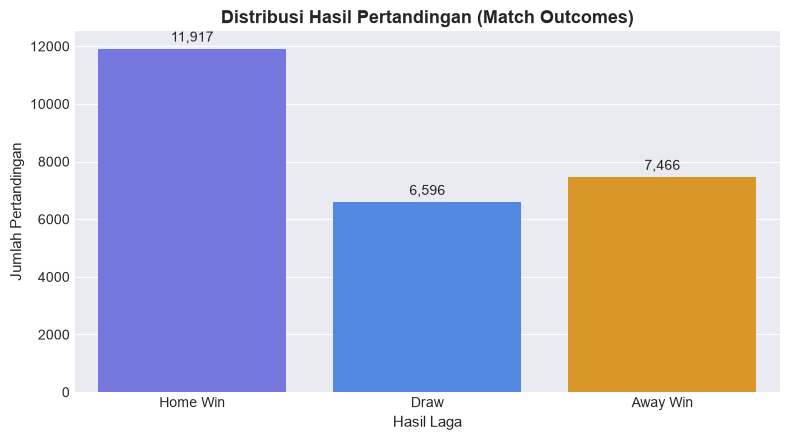

In [11]:
plt.figure(figsize=(8, 4.5))
ax = sns.countplot(
    data=df, 
    x='result', 
    hue='result', 
    order=['Home Win', 'Draw', 'Away Win'], 
    palette=['#3b82f6', '#f59e0b', '#6366f1'],
    legend=False
)
plt.title('Distribusi Hasil Pertandingan (Match Outcomes)', fontsize=13, fontweight='bold')
plt.xlabel('Hasil Laga', fontsize=11)
plt.ylabel('Jumlah Pertandingan', fontsize=11)

# Fitur resmi Matplotlib modern untuk label angka otomatis:
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

# Visualisasi Perbandingan Gol Kandang vs Tandang

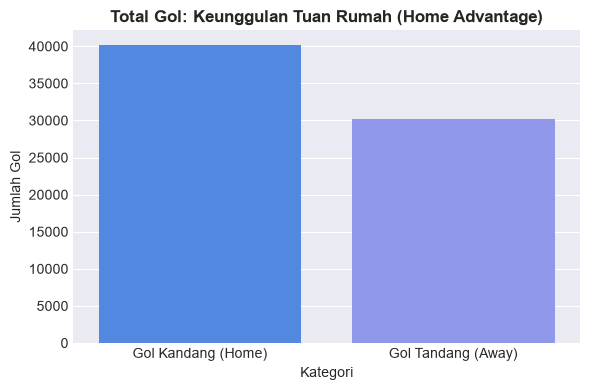

In [12]:
df['home_goals'] = pd.to_numeric(df['home_goals'], errors='coerce')
df['away_goals'] = pd.to_numeric(df['away_goals'], errors='coerce')

goals_df = pd.DataFrame({
    'Kategori': ['Gol Kandang (Home)', 'Gol Tandang (Away)'],
    'Total Gol': [df['home_goals'].sum(), df['away_goals'].sum()]
})

plt.figure(figsize=(6, 4))
sns.barplot(
    data=goals_df, 
    x='Kategori', 
    y='Total Gol', 
    hue='Kategori', 
    palette=['#3b82f6', '#818cf8'],
    legend=False
)
plt.title('Total Gol: Keunggulan Tuan Rumah (Home Advantage)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Gol', fontsize=10)
plt.tight_layout()
plt.show()

# Top 10 Klub Paling Aktif di Dataset

findfont: Failed to find font weight semibold, now using 700.


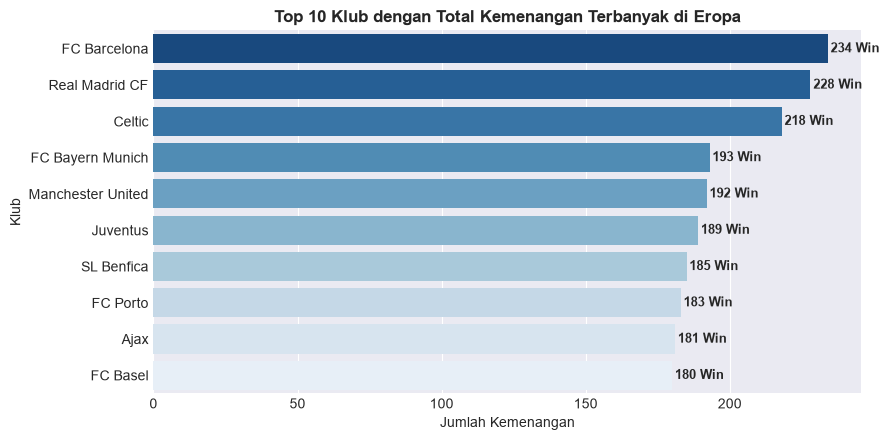

In [13]:
# Hitung total kemenangan (Home Win + Away Win) per klub
home_wins = df[df['result'] == 'Home Win']['home_team'].value_counts()
away_wins = df[df['result'] == 'Away Win']['away_team'].value_counts()
total_wins = (home_wins.add(away_wins, fill_value=0)).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4.5))
sns.barplot(
    x=total_wins.values, 
    y=total_wins.index, 
    hue=total_wins.index, 
    palette='Blues_r',
    legend=False
)
plt.title('Top 10 Klub dengan Total Kemenangan Terbanyak di Eropa', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Kemenangan', fontsize=10)
plt.ylabel('Klub', fontsize=10)

# Beri label angka di ujung batang
for i, v in enumerate(total_wins.values):
    plt.text(v + 1, i, f'{int(v)} Win', va='center', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.show()